# Clinical Production Grad-CAM Visualizer

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🟢 Champion ResNet18 model loaded successfully.


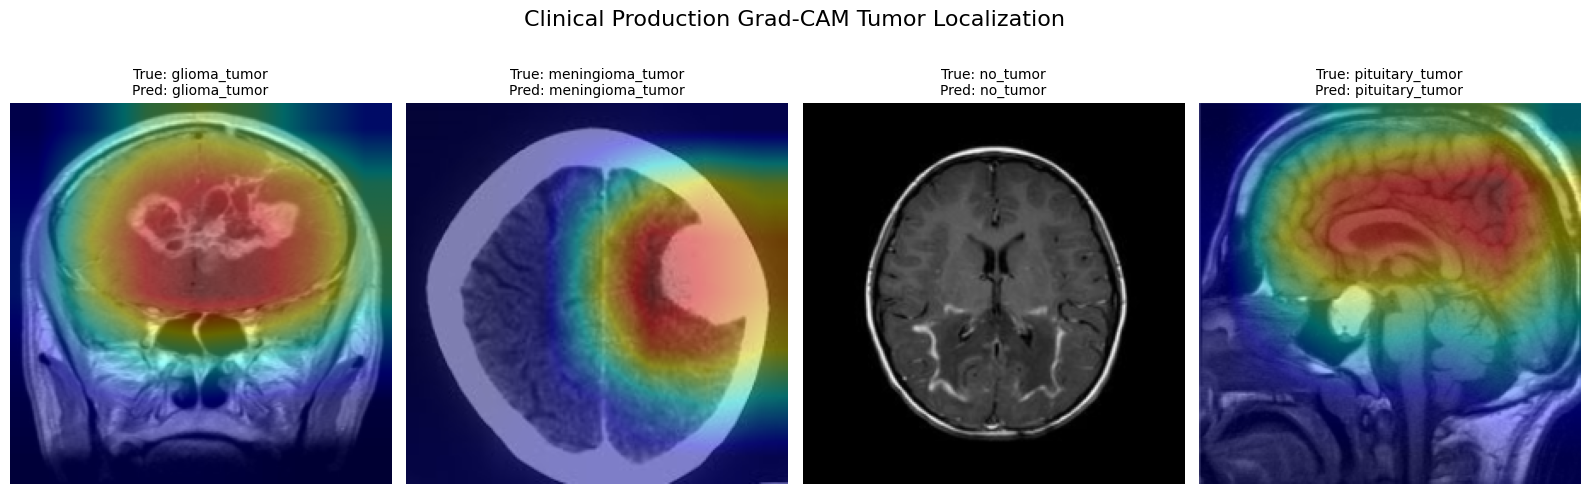

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from google.colab import drive

# 1. Activation and Gradient hooks for Grad-CAM
gradients = None
activations = None

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

def forward_hook(module, input, output):
    global activations
    activations = output

# 2. Environment Setup and Drive Mounting
drive.mount('/content/drive')
dataset_base_path = "./drive/MyDrive/Brain_Tumor_Classification/dataset_extracted/Brain-Tumor-Classification-DataSet-master"
val_dir = os.path.join(dataset_base_path, 'Testing')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. Load the Champion Model Architecture
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 4)

checkpoint_path = "./drive/MyDrive/Brain_Tumor_Classification/best_brain_tumor_model_v3.pth"
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device).eval()
    print("🟢 Champion ResNet18 model loaded successfully.")
else:
    print("❌ Checkpoint file not found!")

# Register hooks on layer4
target_layer = model.layer4[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

# Data Engineering
vis_transforms = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
norm_transform = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

val_dataset = ImageFolder(root=val_dir, transform=vis_transforms)
classes = val_dataset.classes

# Pick 4 distinct sample indices to test
indices = [0, 205, 310, 368]
#indices = [0, 120, 230, 310]

plt.figure(figsize=(16, 10))

for idx, sample_idx in enumerate(indices):
    img_tensor, label_idx = val_dataset[sample_idx]
    img_cv = img_tensor.permute(1, 2, 0).numpy()

    input_tensor = norm_transform(img_tensor).unsqueeze(0).to(device)

    # Execute Model Forward Pass
    outputs = model(input_tensor)
    _, preds = torch.max(outputs, 1)
    pred_class_name = classes[preds.item()]
    true_class_name = classes[label_idx]

    # PRODUCTION CLINICAL FILTER: If the model predicts "no_tumor" (Right or Wrong), DO NOT draw a heatmap!
    if pred_class_name == "no_tumor":
        final_display_img = img_cv  # Show clean MRI to prevent misinterpretation
    else:
        # Execute Grad-CAM only when a tumor is actively detected by the network
        model.zero_grad()
        score = outputs[0, preds.item()]
        score.backward()

        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
        for i in range(activations.size(1)):
            activations[:, i, :, :] *= pooled_gradients[i]

        heatmap = torch.mean(activations, dim=1).squeeze().cpu().detach().numpy()
        heatmap = np.maximum(heatmap, 0)

        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)

        heatmap_resized = cv2.resize(heatmap, (224, 224))
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0

        final_display_img = heatmap_colored * 0.4 + img_cv * 0.6

    # Plotting the final safe visualization
    plt.subplot(2, 4, idx + 1)
    plt.imshow(final_display_img)
    plt.axis('off')
    plt.title(f"True: {true_class_name}\nPred: {pred_class_name}", fontsize=10)

plt.tight_layout()
plt.suptitle("Clinical Production Grad-CAM Tumor Localization", fontsize=16, y=1.02)
plt.show()